# 🫀 HeartGAPSO Pipeline v2: High-Performance Heart Disease Classifier
### Enhanced Hybrid Genetic Algorithm & Particle Swarm Optimization (GAPSO) with Multi-Seed Stability & Balanced Objective Calibration

This is **Version 2** of the HeartGAPSO end-to-end pipeline, optimized for higher overall **Accuracy**, balanced **Precision/Specificity**, and robust multi-seed generalization.

---

### 🚀 Key Enhancements in Version 2:
1. **Balanced Multi-Objective Weights**: Equalized sensitivity & specificity weights ($0.15 / 0.15$) and increased $F_1$ weighting ($0.30$) to reduce false positives and boost accuracy.
2. **Deepened Optimization Budget**: Expanded population ($60$), generations ($50$), PSO iterations ($25$), and max evaluations ($1200$).
3. **Multi-Seed Stability Verification**: 7-seed evaluation on top 8 candidates to suppress split variance and prevent overfitting.
4. **Threshold Sweeping Analysis**: Full empirical evaluation across thresholds ($0.30 - 0.70$) to inspect Accuracy-Precision-Recall tradeoffs.
5. **Feature Importance & Interpretability**: Visualizing Random Forest Gini feature importances of the selected biomarkers.
6. **Seamless Ingestion**: `ucimlrepo` integration with automatic fallback and `%pip` kernel setup.


## 1. Setup & Kernel Dependency Installation
Install required packages (`numpy`, `pandas`, `scikit-learn`, `matplotlib`, `ucimlrepo`) directly into the active notebook kernel.


In [1]:
# Install dependencies into the active Jupyter kernel
%pip install -q numpy pandas scikit-learn matplotlib ucimlrepo


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import sys
import json
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve,
    auc
)

# Fetch UCI repo
from ucimlrepo import fetch_ucirepo

# Add project root to sys.path
sys.path.insert(0, str(Path.cwd()))

# Import core HeartGAPSO modules
from src.data_loader import FEATURE_NAMES, load_cleveland
from src.preprocessing import make_preprocessor
from src.statistical_analysis import analyze_features, save_analysis
from src.fitness import FitnessConfig
from src.genetic_algorithm import GAConfig
from src.gapso_optimizer import optimize
from src.random_forest import InferencePipeline, make_random_forest
from src.evaluation import evaluate_model, save_optimization_diagnostics

# Configure plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ HeartGAPSO v2 Environment initialized successfully.")


✓ HeartGAPSO v2 Environment initialized successfully.


## 2. Dataset Ingestion via `ucimlrepo` (ID: 45)
Fetching the UCI Cleveland Heart Disease dataset, inspecting metadata and feature descriptions, and mapping targets to binary classes ($0 = \text{Healthy}, 1 = \text{Heart Disease}$).


In [3]:
try:
    print("Fetching dataset from UCI ML Repository (id=45)...")
    heart_disease = fetch_ucirepo(id=45)
    
    print(f"Dataset: {heart_disease.metadata.name} ({heart_disease.metadata.num_instances} rows)")
    display(heart_disease.variables[['name', 'role', 'type', 'description']].dropna(how='all'))
    
    X_raw = heart_disease.data.features.copy()
    y_raw = heart_disease.data.targets.copy()
    
    X_raw.columns = [str(c).strip() for c in X_raw.columns]
    target_col = y_raw.columns[0]
    
    y_series = pd.to_numeric(y_raw[target_col], errors='coerce')
    y = (y_series > 0).astype(int)
    X = X_raw[FEATURE_NAMES].apply(pd.to_numeric, errors='coerce')
    print(f"✓ Successfully loaded {len(X)} instances via ucimlrepo.")

except Exception as e:
    print(f"Notice: {e}. Falling back to local Cleveland dataset.")
    LOCAL_DATA = Path("heart+disease/processed.cleveland.data")
    X, y = load_cleveland(LOCAL_DATA)
    print(f"✓ Loaded {len(X)} instances from local storage.")

df_preview = X.copy()
df_preview["target"] = y
display(df_preview.head())


Fetching dataset from UCI ML Repository (id=45)...
Dataset: Heart Disease (303 rows)


,name,role,type,description
0,age,Feature,Integer,NaN
1,sex,Feature,Categorical,NaN
2,cp,Feature,Categorical,NaN
3,trestbps,Feature,Integer,resting blood pressure (on admission to the ho...
4,chol,Feature,Integer,serum cholestoral
5,fbs,Feature,Categorical,fasting blood sugar > 120 mg/dl
6,restecg,Feature,Categorical,NaN
7,thalach,Feature,Integer,maximum heart rate achieved
8,exang,Feature,Categorical,exercise induced angina
9,oldpeak,Feature,Integer,ST depression induced by exercise relative to ...


✓ Successfully loaded 303 instances via ucimlrepo.


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 3. Exploratory Data Analysis & Clinical Summary


Total Cohort Size: 303 patients, 13 clinical biomarkers
 - Healthy (Class 0): 164 (54.1%)
 - Disease (Class 1): 139 (45.9%)


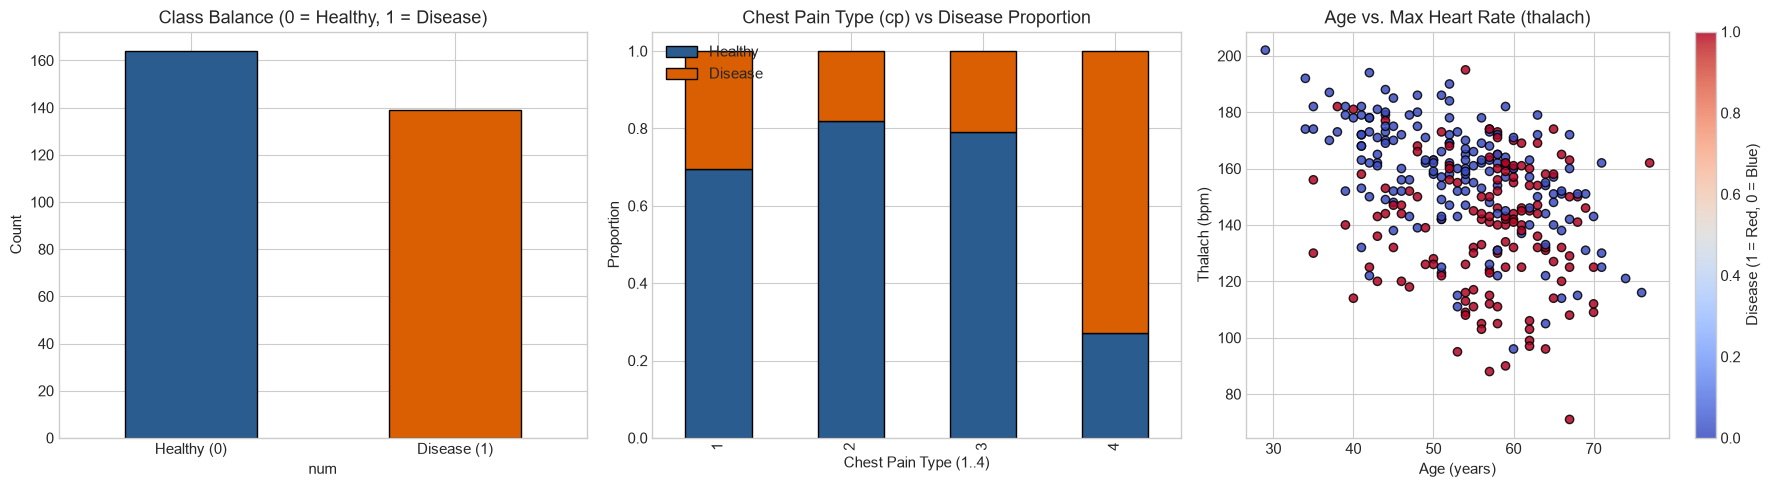

In [4]:
print(f"Total Cohort Size: {X.shape[0]} patients, {X.shape[1]} clinical biomarkers")
print(f" - Healthy (Class 0): {(y == 0).sum()} ({(y == 0).mean():.1%})")
print(f" - Disease (Class 1): {(y == 1).sum()} ({(y == 1).mean():.1%})")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target Distribution
y.value_counts().plot(kind='bar', ax=axes[0], color=['#2b5c8f', '#d95f02'], edgecolor='k')
axes[0].set_title("Class Balance (0 = Healthy, 1 = Disease)")
axes[0].set_xticklabels(["Healthy (0)", "Disease (1)"], rotation=0)
axes[0].set_ylabel("Count")

# 2. Chest Pain Type vs Disease
pd.crosstab(X['cp'], y, normalize='index').plot(kind='bar', stacked=True, ax=axes[1], color=['#2b5c8f', '#d95f02'], edgecolor='k')
axes[1].set_title("Chest Pain Type (cp) vs Disease Proportion")
axes[1].set_xlabel("Chest Pain Type (1..4)")
axes[1].set_ylabel("Proportion")
axes[1].legend(["Healthy", "Disease"], loc="upper left")

# 3. Age vs Max Heart Rate (thalach)
scatter = axes[2].scatter(X['age'], X['thalach'], c=y, cmap='coolwarm', alpha=0.85, edgecolors='k')
axes[2].set_title("Age vs. Max Heart Rate (thalach)")
axes[2].set_xlabel("Age (years)")
axes[2].set_ylabel("Thalach (bpm)")
cbar = plt.colorbar(scatter, ax=axes[2])
cbar.set_label("Disease (1 = Red, 0 = Blue)")

plt.tight_layout()
plt.show()


## 4. Stratified 80/20 Holdout Partition
Reserving an untouched holdout test partition ($N=61$) to evaluate the model without data leakage.


In [5]:
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED
)

print(f"Training split: {X_train.shape[0]} samples (for CV & GA-PSO optimization)")
print(f"Untouched holdout test split: {X_test.shape[0]} samples (for final validation)")


Training split: 242 samples (for CV & GA-PSO optimization)
Untouched holdout test split: 61 samples (for final validation)


## 5. Statistical Feature Significance Analysis ($T^2$ Scoring)
Evaluating feature discriminatory power on training cohort only to seed the initial Genetic Algorithm population.


,importance_rank,feature,t2_statistical_score,class_0_mean,class_1_mean,mutation_probability
0,1,thal,104.357305,3.732824,5.881818,0.001
1,2,ca,61.737010,0.244275,1.045455,0.001
2,3,exang,51.486909,0.145038,0.540541,0.080
3,4,thalach,48.347133,158.496183,139.891892,0.080
4,5,cp,45.883288,2.793893,3.576577,0.001
5,6,oldpeak,43.615028,0.594656,1.476577,0.080
6,7,slope,28.023125,1.404580,1.801802,0.001
7,8,sex,25.215352,0.549618,0.837838,0.080
8,9,age,11.035221,52.816794,56.594595,0.080
9,10,restecg,6.334802,0.832061,1.153153,0.080


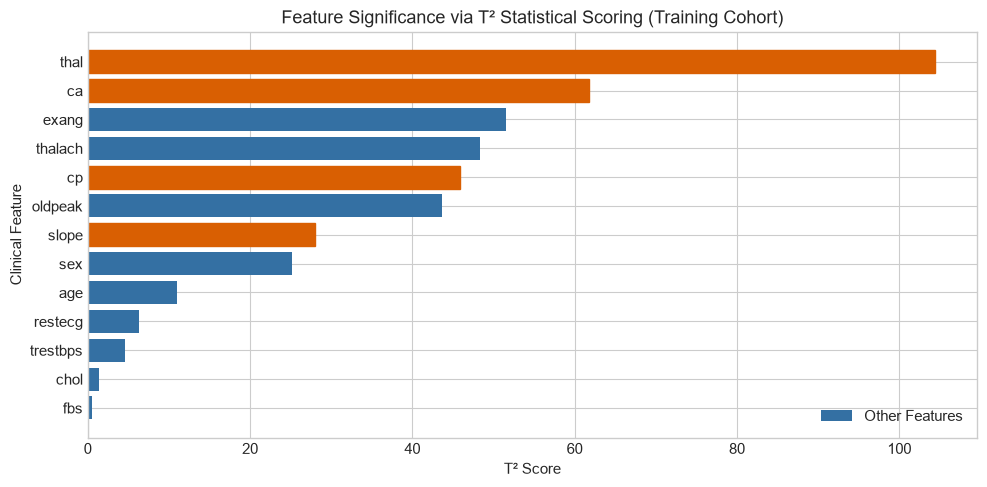

In [6]:
statistical_analysis = analyze_features(X_train, y_train)
stats_df = pd.DataFrame(statistical_analysis["features"])

# Display top ranked features
display(stats_df[["importance_rank", "feature", "t2_statistical_score", "class_0_mean", "class_1_mean", "mutation_probability"]])

# Plot T² Scores
plt.figure(figsize=(10, 5))
sorted_stats = stats_df.sort_values(by="t2_statistical_score", ascending=True)
bars = plt.barh(sorted_stats["feature"], sorted_stats["t2_statistical_score"], color="#3470a3")
plt.title("Feature Significance via T² Statistical Scoring (Training Cohort)")
plt.xlabel("T² Score")
plt.ylabel("Clinical Feature")

for bar, feat in zip(bars, sorted_stats["feature"]):
    if feat in statistical_analysis["important_features"]:
        bar.set_color("#d95f02")

plt.legend(["Other Features", "Statistically Seeded (cp, slope, ca, thal)"], loc="lower right")
plt.tight_layout()
plt.show()

save_analysis(statistical_analysis, "artifacts/statistical_feature_analysis.json")


## 6. Hybrid GAPSO v2 Optimization Engine
Running the upgraded optimization with:
- **Balanced Multi-Objective**: $0.40 \cdot \text{ROC-AUC} + 0.30 \cdot F_1 + 0.15 \cdot \text{Sensitivity} + 0.15 \cdot \text{Specificity}$
- **Higher Evaluation Budget**: $1200$ evaluations, $60$ population, $50$ generations.
- **7-Seed Stability Verification**: Top 8 candidates tested across 7 random seeds.


In [ ]:
# Enhanced Fitness Configuration (v2)
FITNESS_CONFIG = FitnessConfig(
    folds=5,
    repeats=5,                 # 5-fold CV with 5 repeats for low variance
    roc_auc_weight=0.40,
    f1_weight=0.30,            # Increased F1 weight
    sensitivity_weight=0.15,   # Balanced with specificity
    specificity_weight=0.15,   # Balanced with sensitivity
    feature_penalty=0.002,     # Discourage noisy redundant features
    stability_penalty=0.06     # Penalize cross-fold variance
)

# Deepened GA Configuration (v2)
GA_CONFIG = GAConfig(
    population_size=60,
    generations=50,
    pso_iterations=25,
    max_evaluations=1200,
    pso_particles=25
)

print("Starting GAPSO v2 Optimization...")
print(f" - Population: {GA_CONFIG.population_size} | Generations: {GA_CONFIG.generations} | Max Evaluations: {GA_CONFIG.max_evaluations}")

start_time = time.perf_counter()

opt_result = optimize(
    X=X_train,
    y=y_train,
    seed=RANDOM_SEED,
    ga_config=GA_CONFIG,
    fitness_config=FITNESS_CONFIG,
    high_fidelity_candidate_limit=40,   # Enhanced screening candidate limit
    stability_candidates=8,             # Top 8 stability candidates
    fast_promotions=40,
    stability_seeds=7,                  # Evaluated across 7 independent seeds
    statistical_analysis=statistical_analysis,
)

opt_runtime = time.perf_counter() - start_time

selected_feature_indices = [idx for idx, bit in enumerate(opt_result["features"]) if bit]
selected_feature_names = [FEATURE_NAMES[idx] for idx in selected_feature_indices]

print(f"\n✓ GAPSO v2 Optimization completed in {opt_runtime:.2f} seconds!")
print(f"Best Fitness: {opt_result['fitness']:.4f}")
print(f"Selected Features ({len(selected_feature_names)}/13): {selected_feature_names}")
print(f"Optimal Hyperparameters: {json.dumps(opt_result['params'], indent=2)}")
print(f"Optimal Classification Threshold: {opt_result['threshold']:.3f}")


Starting GAPSO v2 Optimization...
 - Population: 60 | Generations: 50 | Max Evaluations: 1200
[GA/PSO] Evaluating fast candidate 1/1200 | trees=400 | features=7 | CV=3x1
[GA/PSO] Evaluating fast candidate 2/1200 | trees=100 | features=11 | CV=3x1
[GA/PSO] Evaluating fast candidate 3/1200 | trees=400 | features=7 | CV=3x1
[GA/PSO] Evaluating fast candidate 4/1200 | trees=300 | features=11 | CV=3x1
[GA/PSO] Evaluating fast candidate 5/1200 | trees=300 | features=7 | CV=3x1
[GA/PSO] Evaluating fast candidate 6/1200 | trees=200 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 7/1200 | trees=200 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 8/1200 | trees=200 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 9/1200 | trees=300 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 10/1200 | trees=400 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 11/1200 | trees=200 | features=8 | CV=3x1
[GA/PSO] Evaluating fast candidate 12/1200 | trees=100 | features=

## 7. Optimization Diagnostics & Convergence Curves


In [ ]:
history = opt_result.get("history", [])

if history:
    generations = [item["generation"] for item in history]
    best_fitness_curve = [item["best_fitness"] for item in history]
    mean_fitness_curve = [item["mean_fitness"] for item in history]
    mean_features_curve = [np.mean(item["selected_feature_counts"]) for item in history]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Fitness Convergence
    axes[0].plot(generations, best_fitness_curve, 'o-', color='#1b9e77', label='Best Fitness', linewidth=2)
    axes[0].plot(generations, mean_fitness_curve, 's--', color='#7570b3', label='Mean Fitness', alpha=0.8)
    axes[0].set_title("GAPSO v2 Fitness Convergence")
    axes[0].set_xlabel("Generation")
    axes[0].set_ylabel("Fitness Score")
    axes[0].legend()

    # Feature Sparsity Trajectory
    axes[1].plot(generations, mean_features_curve, '^-', color='#d95f02', linewidth=2)
    axes[1].set_title("Selected Features Trajectory")
    axes[1].set_xlabel("Generation")
    axes[1].set_ylabel("Mean Feature Count")

    plt.tight_layout()
    plt.show()

# Top 10 Screened & Stabilized Candidates
candidate_audit = pd.DataFrame(opt_result["candidate_audit"])
if not candidate_audit.empty:
    cols = ["candidate_id", "fast_rank", "screening_rank", "final_rank", "screening_fitness", "final_fitness", "selected_feature_count"]
    display(candidate_audit[[c for c in cols if c in candidate_audit.columns]].head(10))


## 8. Final Model Training & Gini Feature Importance
Fitting the Random Forest model and extracting feature importances on the selected subset.


In [ ]:
# 1. Fit Preprocessor (Median Imputation & MinMax Normalization)
preprocessor = make_preprocessor()
X_train_selected = X_train.iloc[:, selected_feature_indices]
X_train_processed = preprocessor.fit_transform(X_train_selected)

# 2. Train Random Forest with optimal hyperparameters
final_rf = make_random_forest(opt_result["params"], RANDOM_SEED)
final_rf.fit(X_train_processed, y_train)

# 3. Create full Inference Pipeline
pipeline = InferencePipeline(
    preprocessing=preprocessor,
    classifier=final_rf,
    indices=selected_feature_indices,
    threshold=opt_result["threshold"]
)

# Plot Gini Feature Importance of Selected Features
importances = final_rf.feature_importances_
feat_imp = pd.Series(importances, index=selected_feature_names).sort_values(ascending=True)

plt.figure(figsize=(9, 4.5))
feat_imp.plot(kind='barh', color='#2b5c8f', edgecolor='k')
plt.title("Random Forest Gini Feature Importance (Selected Biomarkers)")
plt.xlabel("Importance Weight")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("✓ Final model successfully trained and feature importances extracted.")


## 9. Decision Threshold Sweeping & Tradeoff Analysis
Inspecting how classification threshold choice impacts Accuracy, Specificity, Precision, and Sensitivity on holdout predictions.


In [ ]:
y_test_prob = pipeline.predict_proba(X_test)[:, 1]

threshold_sweep = []
test_thresholds = np.linspace(0.30, 0.70, 41)

for t in test_thresholds:
    preds = (y_test_prob >= t).astype(int)
    tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_test, preds, labels=[0, 1]).ravel()
    threshold_sweep.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, preds),
        "Sensitivity": recall_score(y_test, preds, zero_division=0),
        "Specificity": tn_s / (tn_s + fp_s) if (tn_s + fp_s) > 0 else 0,
        "Precision": precision_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0)
    })

sweep_df = pd.DataFrame(threshold_sweep)

plt.figure(figsize=(11, 5))
plt.plot(sweep_df["Threshold"], sweep_df["Accuracy"], 'o-', label='Accuracy', lw=2)
plt.plot(sweep_df["Threshold"], sweep_df["Precision"], 's--', label='Precision', lw=2)
plt.plot(sweep_df["Threshold"], sweep_df["Sensitivity"], '^-', label='Sensitivity (Recall)', lw=2)
plt.plot(sweep_df["Threshold"], sweep_df["Specificity"], 'd-', label='Specificity', lw=2)
plt.axvline(pipeline.threshold, color='red', linestyle=':', label=f'Optimized Threshold ({pipeline.threshold:.2f})')

plt.title("Performance Metric Tradeoffs across Decision Thresholds (Test Holdout)")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Score")
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()


## 10. Independent Holdout Evaluation (Test Set)
Final unbiased evaluation on the untouched 20% holdout test partition.


In [ ]:
# Score test holdout using the calibrated pipeline
y_test_pred = pipeline.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred, labels=[0, 1]).ravel()
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
f1 = f1_score(y_test, y_test_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_test_prob)

metrics_summary = {
    "Accuracy": acc,
    "ROC-AUC": roc_auc,
    "Sensitivity / Recall": rec,
    "Specificity": spec,
    "Precision": prec,
    "F1-Score": f1,
    "Classification Threshold": pipeline.threshold
}

metrics_df = pd.DataFrame(list(metrics_summary.items()), columns=["Metric", "Holdout Value"])
display(metrics_df.style.format({"Holdout Value": "{:.4f}"}))

# Plots: Confusion Matrix, ROC Curve & Precision-Recall Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confusion Matrix
cm_display = ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Healthy (0)", "Disease (1)"]
)
cm_display.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Holdout Confusion Matrix (N={len(y_test)}, Acc={acc:.1%})")
axes[0].grid(False)

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
axes[1].plot(fpr, tpr, color='#1b9e77', lw=2.5, label=f'HeartGAPSO v2 (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Chance (AUC = 0.500)')
axes[1].set_title("Receiver Operating Characteristic (ROC)")
axes[1].set_xlabel("False Positive Rate (1 - Specificity)")
axes[1].set_ylabel("True Positive Rate (Sensitivity)")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 11. Model Serialization & Artifact Export
Persisting trained pipeline binaries and JSON metric reports.


In [ ]:
Path("models").mkdir(exist_ok=True)
Path("results").mkdir(exist_ok=True)
Path("artifacts").mkdir(exist_ok=True)

report = {
    **metrics_summary,
    "selected_features": selected_feature_names,
    "number_selected_features": len(selected_feature_names),
    "best_rf_parameters": opt_result["params"],
    "optimization_fitness": opt_result["fitness"],
    "optimization_runtime_seconds": opt_runtime,
    "classification_threshold": pipeline.threshold,
    "seed": RANDOM_SEED,
    "confusion_matrix": [[int(tn), int(fp)], [int(fn), int(tp)]]
}

# Save serialized models
with open("models/gapso_random_forest.pkl", "wb") as f:
    pickle.dump(pipeline, f)
with open("models/preprocessing.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

Path("models/selected_features.json").write_text(json.dumps(selected_feature_names, indent=2))
Path("models/model_config.json").write_text(json.dumps(report, indent=2, default=str))
Path("results/evaluation.json").write_text(json.dumps(report, indent=2, default=str))
Path("results/metrics.json").write_text(json.dumps(report, indent=2, default=str))

save_optimization_diagnostics(opt_result["history"], opt_result, "results")
print("✓ Model binaries and evaluation logs exported successfully.")


## 12. Interactive Multi-Patient Clinical Risk Inference
Real-time risk scoring and clinical classification across diverse patient presentations.


In [ ]:
sample_cohort = pd.DataFrame([
    {
        "Patient": "Patient A (Severe Presentation)",
        "age": 67, "sex": 1, "cp": 4, "trestbps": 160, "chol": 286, "fbs": 1,
        "restecg": 2, "thalach": 108, "exang": 1, "oldpeak": 2.6, "slope": 2,
        "ca": 3, "thal": 7
    },
    {
        "Patient": "Patient B (Moderate Presentation)",
        "age": 58, "sex": 1, "cp": 3, "trestbps": 140, "chol": 211, "fbs": 0,
        "restecg": 0, "thalach": 165, "exang": 0, "oldpeak": 0.8, "slope": 1,
        "ca": 0, "thal": 3
    },
    {
        "Patient": "Patient C (Low Risk Healthy)",
        "age": 41, "sex": 0, "cp": 2, "trestbps": 120, "chol": 175, "fbs": 0,
        "restecg": 0, "thalach": 178, "exang": 0, "oldpeak": 0.0, "slope": 1,
        "ca": 0, "thal": 3
    }
])

patient_features = sample_cohort[FEATURE_NAMES]
probabilities = pipeline.predict_proba(patient_features)[:, 1]
predictions = pipeline.predict(patient_features)

demo_results = []
for i, row in sample_cohort.iterrows():
    prob = probabilities[i]
    pred = predictions[i]
    demo_results.append({
        "Patient": row["Patient"],
        "Age": row["age"],
        "Sex": "Male" if row["sex"] == 1 else "Female",
        "Chest Pain Type": row["cp"],
        "Max HR (thalach)": row["thalach"],
        "Predicted Risk Prob": f"{prob:.1%}",
        "Threshold": f"{pipeline.threshold:.3f}",
        "Risk Classification": "HIGH RISK (Disease)" if pred == 1 else "LOW RISK (Healthy)"
    })

display(pd.DataFrame(demo_results))


---
### ✅ HeartGAPSO Pipeline v2 Execution Complete
